<a href="https://colab.research.google.com/github/tharun-7733/scheduling-maintainence-visits-of-medical-equipment/blob/main/POC_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Importing required libraries

---


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report,
    r2_score, mean_absolute_error, mean_squared_error
)

from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVC, SVR
from xgboost import XGBClassifier, XGBRegressor
from sklearn.preprocessing import StandardScaler
from IPython.display import display

import joblib
import os


2. Load the Dataset

---



In [37]:
data = pd.read_csv("/content/Medical_Device_Failure_dataset.csv")

3. Dataset Frame Overview

---



In [38]:
df = pd.DataFrame(data)

In [39]:
data.head()

,Device_ID,Device_Type,Purchase_Date,Age,Manufacturer,Model,Country,Maintenance_Cost,Downtime,Maintenance_Frequency,Failure_Event_Count,Maintenance_Class,Maintenance_Report
0,MD03449,Defibrillator,2018-04-23,7,CardioSync,Model-100,France,7115.349585,7.933824,3,0,1,Component component upgrade after detecting ov...
1,MD02024,Infusion Pump,2020-12-10,5,MedEquip,Model-650,Italy,7290.780658,7.838711,3,4,2,battery wear caused operational delay; replace...
2,MD04239,MRI Scanner,2023-11-22,2,ImagingTech,Model-650,France,5635.521788,13.911045,1,2,3,data lag caused operational delay; component u...
3,MD00153,Defibrillator,2021-03-03,4,RescueTech,Model-450,UK,5001.360188,29.059510,3,1,3,Routine check completed; battery wear observed...
4,MD03743,Defibrillator,2019-05-16,6,RescueTech,Model-450,Canada,7555.132928,13.942355,4,4,2,Component inspection after detecting voltage s...


4. DataFrame creation

5. Data Inspection

---



In [40]:
print("---- Info ----")
print(df.info())
print("\n---- Describe (numeric) ----")
display(df.describe().T)
print("\n---- Missing values per column ----")
display(df.isnull().sum())
print("\n---- Duplicated rows ----")
print(df.duplicated().sum())

---- Info ----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4149 entries, 0 to 4148
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Device_ID              4149 non-null   object 
 1   Device_Type            4149 non-null   object 
 2   Purchase_Date          4149 non-null   object 
 3   Age                    4149 non-null   int64  
 4   Manufacturer           4149 non-null   object 
 5   Model                  4149 non-null   object 
 6   Country                4149 non-null   object 
 7   Maintenance_Cost       4149 non-null   float64
 8   Downtime               4149 non-null   float64
 9   Maintenance_Frequency  4149 non-null   int64  
 10  Failure_Event_Count    4149 non-null   int64  
 11  Maintenance_Class      4149 non-null   int64  
 12  Maintenance_Report     4149 non-null   object 
dtypes: float64(2), int64(4), object(7)
memory usage: 421.5+ KB
None

---- Describe (numeric) ----

,count,mean,std,min,25%,50%,75%,max
Age,4149.0,6.717763,3.175610,1.000000,4.000000,7.000000,9.000000,12.000000
Maintenance_Cost,4149.0,8643.595669,5930.038551,-5747.932890,4451.775127,7213.575604,12023.912821,34937.222389
Downtime,4149.0,10.621367,7.099434,0.950068,5.066061,8.862348,14.638223,34.152648
Maintenance_Frequency,4149.0,3.011810,1.421730,1.000000,2.000000,3.000000,4.000000,5.000000
Failure_Event_Count,4149.0,1.957821,1.413328,0.000000,1.000000,2.000000,3.000000,10.000000
Maintenance_Class,4149.0,2.000000,0.816595,1.000000,1.000000,2.000000,3.000000,3.000000



---- Missing values per column ----


,0
Device_ID,0
Device_Type,0
Purchase_Date,0
Age,0
Manufacturer,0
Model,0
Country,0
Maintenance_Cost,0
Downtime,0
Maintenance_Frequency,0



---- Duplicated rows ----
0


In [41]:
df.dtypes

,0
Device_ID,object
Device_Type,object
Purchase_Date,object
Age,int64
Manufacturer,object
Model,object
Country,object
Maintenance_Cost,float64
Downtime,float64
Maintenance_Frequency,int64


In [42]:
print("Unique counts per column")
display(df.nunique().head())



numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical columns: ", numerical_cols)
print("Categorical columns: ", categorical_cols)

Unique counts per column


,0
Device_ID,4149
Device_Type,6
Purchase_Date,2563
Age,12
Manufacturer,6


Numerical columns:  ['Age', 'Maintenance_Cost', 'Downtime', 'Maintenance_Frequency', 'Failure_Event_Count', 'Maintenance_Class']
Categorical columns:  ['Device_ID', 'Device_Type', 'Purchase_Date', 'Manufacturer', 'Model', 'Country', 'Maintenance_Report']


6. Removal of Unwanted data

In [43]:
df = df.dropna(axis=1, how='all')
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f'Before removing duplicates: {before}')
print(f'After removing duplicates: {after}')

Before removing duplicates: 4149
After removing duplicates: 4149


7. Feature Engineering

In [44]:
df["Maintenance_Report"] = df["Maintenance_Report"].fillna("")

df["Report_Length"] = df["Maintenance_Report"].apply(len)
df["Word_Count"] = df["Maintenance_Report"].apply(lambda x: len(x.split()))


df["Contain_Failure"] = df["Maintenance_Report"].str.contains("failure|shutdown|error", case=False).astype(int)
df["Contain_Wear"] = df["Maintenance_Report"].str.contains("wear|degradation|deterioration", case=False).astype(int)
df["Contain_Replace"] = df["Maintenance_Report"].str.contains("replace|replacement", case=False).astype(int)

In [45]:
# 4.2 Interaction / severity / efficiency
df["Severity_Score"] = df["Failure_Event_Count"] * df["Downtime"]
df["Efficiency"] = df["Maintenance_Cost"] / (df["Downtime"] + 1)

In [46]:
# Age group
df["Age_Group"] = pd.cut(
    df["Age"], bins=[0, 5, 10, 20, 50, 100],
    labels=[1, 2, 3, 4, 5], include_lowest=True
).astype(int)

# Failure types
failure_types = {
    "battery__Issue": ["battery", "power", "drain"],
    "sensor__Issue": ["sensor", "signal", "detect"],
    "circuit__Issue": ["circuit", "board", "electric"],
    "software__Issue": ["software", "firmware", "update"],
    "overheat__Issue": ["heat", "overheat", "temp", "temperature"],
    "delay__Issue": ["delay", "slow", "lag"]
}

In [47]:
for col, words in failure_types.items():
    pattern = "|".join(words)
    df[col] = df["Maintenance_Report"].str.contains(pattern, case=False).astype(int)


df["Maintenance_per_Fail"] = df["Maintenance_Frequency"] / (df["Failure_Event_Count"] + 1)

df["FailRate_Per_Age"] = df["Failure_Event_Count"] / (df["Age"] + 1)
df["Downtime_Per_Event"] = df["Downtime"] / (df["Failure_Event_Count"] + 1)

df["Downtime_cu"] = df["Downtime"] ** 3
df["Cost_cu"] = df["Maintenance_Cost"] ** 3
df["Failure_cu"] = df["Failure_Event_Count"] ** 3

df["Failure_X_Downtime"] = df["Contain_Failure"] * df["Downtime"]
df["Sensor_X_Age"] = df["sensor__Issue"] * df["Age"]
df["Battery_X_Cost"] = df["battery__Issue"] * df["Maintenance_Cost"]

df["Cost_Is_Outlier"] = (df["Maintenance_Cost"] > df["Maintenance_Cost"].quantile(0.95)).astype(int)
df["Downtime_Is_Outlier"] = (df["Downtime"] > df["Downtime"].quantile(0.95)).astype(int)

df["Report_Severity_Level"] = (
    df["Contain_Failure"] * 3 +
    df["Contain_Wear"] * 2 +
    df["Contain_Replace"]
)

print("\nFeature engineering completed. Columns now:")
print(df.columns)


Feature engineering completed. Columns now:
Index(['Device_ID', 'Device_Type', 'Purchase_Date', 'Age', 'Manufacturer',
       'Model', 'Country', 'Maintenance_Cost', 'Downtime',
       'Maintenance_Frequency', 'Failure_Event_Count', 'Maintenance_Class',
       'Maintenance_Report', 'Report_Length', 'Word_Count', 'Contain_Failure',
       'Contain_Wear', 'Contain_Replace', 'Severity_Score', 'Efficiency',
       'Age_Group', 'battery__Issue', 'sensor__Issue', 'circuit__Issue',
       'software__Issue', 'overheat__Issue', 'delay__Issue',
       'Maintenance_per_Fail', 'FailRate_Per_Age', 'Downtime_Per_Event',
       'Downtime_cu', 'Cost_cu', 'Failure_cu', 'Failure_X_Downtime',
       'Sensor_X_Age', 'Battery_X_Cost', 'Cost_Is_Outlier',
       'Downtime_Is_Outlier', 'Report_Severity_Level'],
      dtype='object')


Encoding

In [48]:
df = pd.get_dummies(df, columns=["Device_Type", "Manufacturer", "Model", "Country"], drop_first=True)


8. Outlier Handling

In [49]:
def handle_outliers_iqr(df_in, columns):
    df_out = df_in.copy()
    for col in columns:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_out[col] = np.clip(df_out[col], lower_bound, upper_bound)
    return df_out

numeric_cols_for_outliers = ['Downtime', 'Failure_Event_Count', 'Age']
df = handle_outliers_iqr(df, numeric_cols_for_outliers)

9. Filling Missing Values

In [50]:
for col in numerical_cols:
    if col in df.columns and df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

for col in categorical_cols:
    if col in df.columns and df[col].isnull().any():
        mode_val = df[col].mode()
        df[col].fillna(mode_val.iloc[0] if not mode_val.empty else "Unknown", inplace=True)

print("Missing values after handling")
display(df.isnull().sum())

Missing values after handling


,0
Device_ID,0
Purchase_Date,0
Age,0
Maintenance_Cost,0
Downtime,0
...,...
Country_France,0
Country_Italy,0
Country_Japan,0
Country_UK,0


10. EDA (Exploratory Data Analysis)

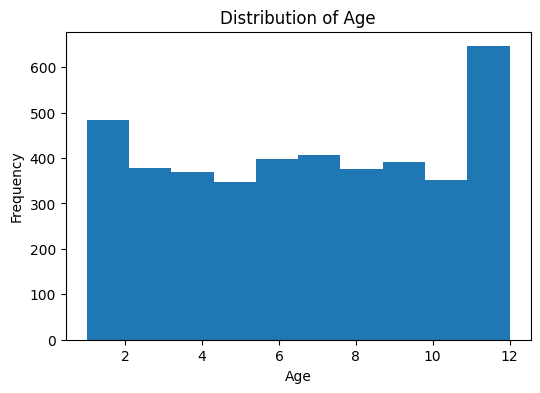

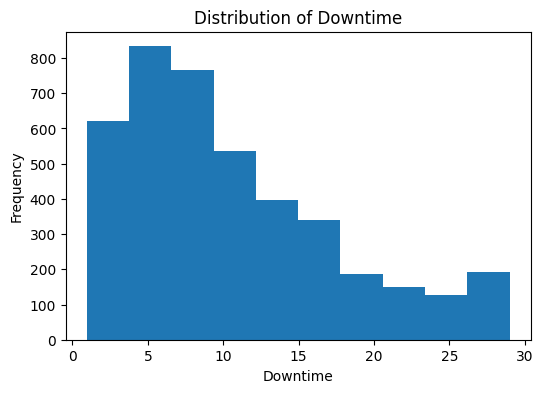

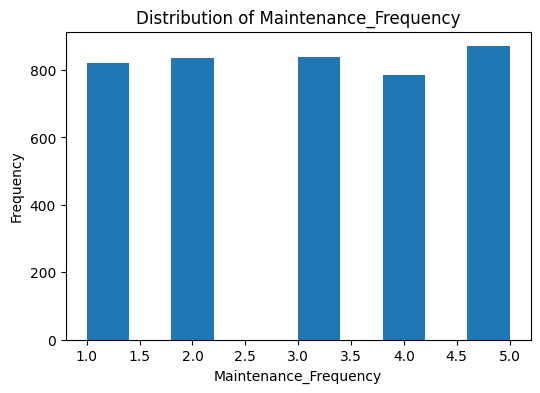

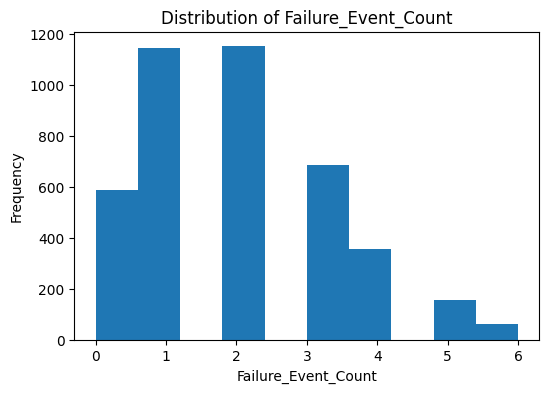

In [51]:
numeric_cols = ["Age", "Downtime",
                "Maintenance_Frequency", "Failure_Event_Count"]

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col].dropna())
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


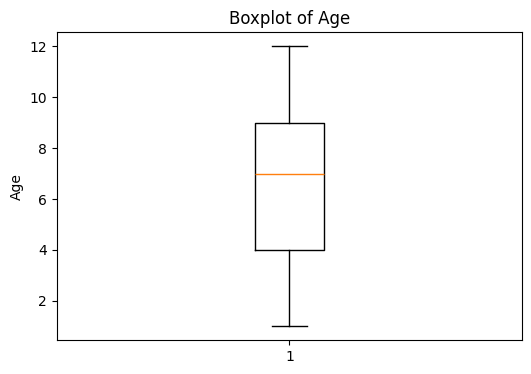

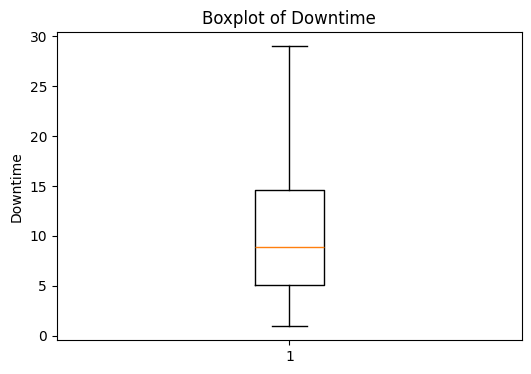

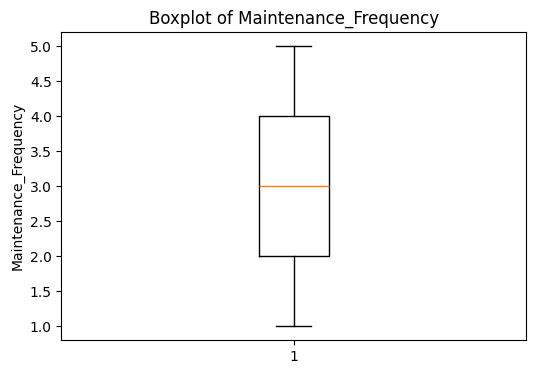

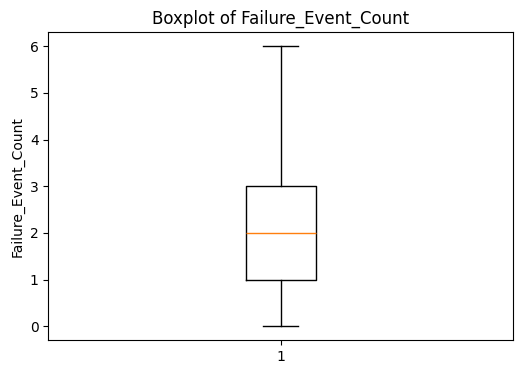

In [52]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()


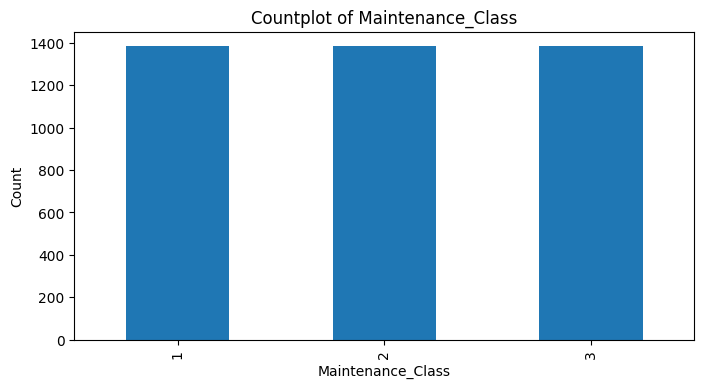

In [53]:
cat_cols = ["Maintenance_Class"]

for col in cat_cols:
    plt.figure(figsize=(8,4))
    df[col].value_counts().plot(kind="bar")
    plt.title(f"Countplot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

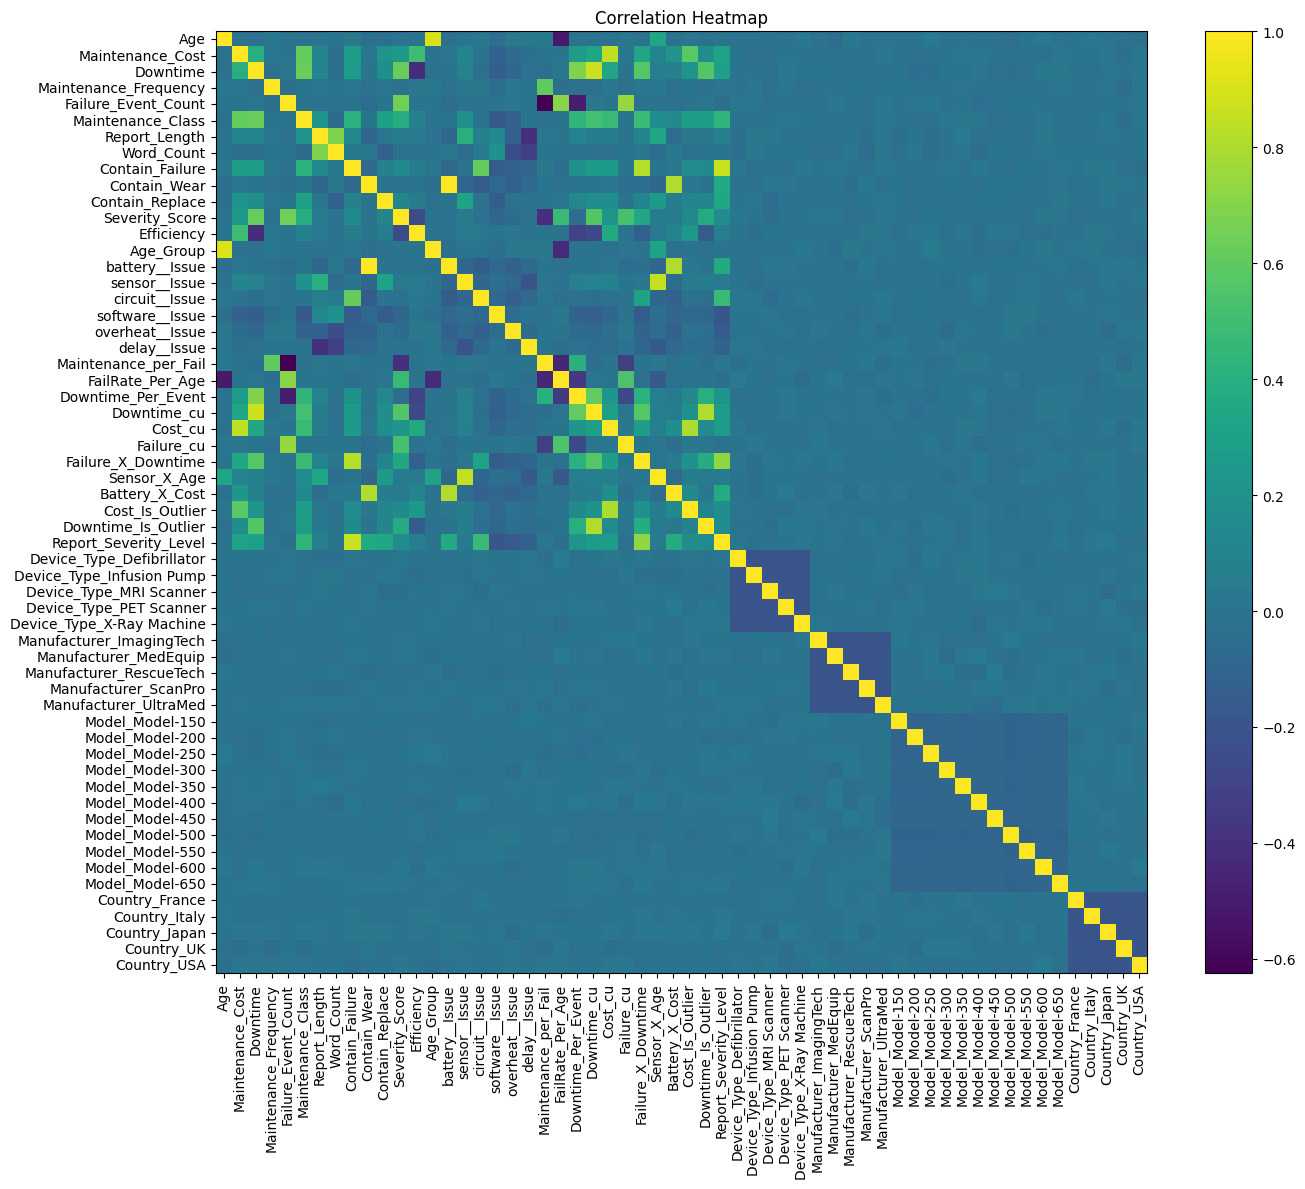

In [54]:
# Compute correlation matrix (numeric only)
corr = df.corr(numeric_only=True)

# Plot clean heatmap
plt.figure(figsize=(14, 12))  # Slightly larger for proper label spacing
plt.imshow(corr, aspect='auto')
plt.title("Correlation Heatmap")

plt.colorbar()


plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90,
    ha='center'
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns,
    va='center'
)

# Fix spacing so labels are not cut off
plt.tight_layout()
plt.show()


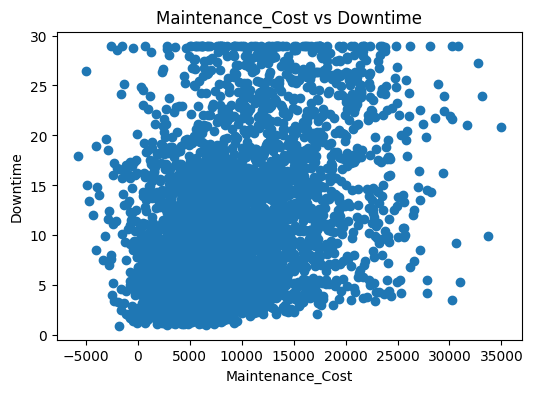

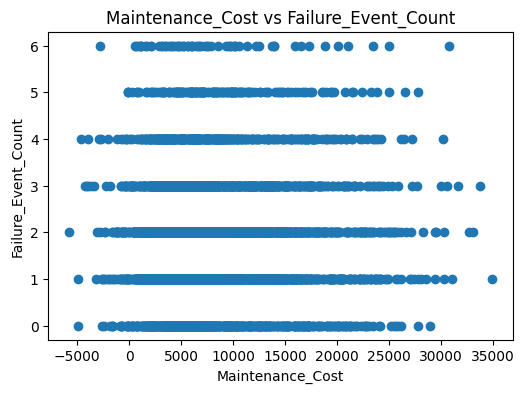

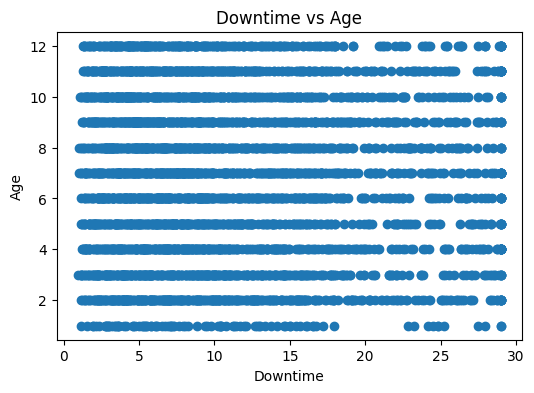

In [55]:
# Cost vs Downtime
plt.figure(figsize=(6,4))
plt.scatter(df["Maintenance_Cost"], df["Downtime"])
plt.title("Maintenance_Cost vs Downtime")
plt.xlabel("Maintenance_Cost")
plt.ylabel("Downtime")
plt.show()

# Cost vs Failure Count
plt.figure(figsize=(6,4))
plt.scatter(df["Maintenance_Cost"], df["Failure_Event_Count"])
plt.title("Maintenance_Cost vs Failure_Event_Count")
plt.xlabel("Maintenance_Cost")
plt.ylabel("Failure_Event_Count")
plt.show()

# Downtime vs Age
plt.figure(figsize=(6,4))
plt.scatter(df["Downtime"], df["Age"])
plt.title("Downtime vs Age")
plt.xlabel("Downtime")
plt.ylabel("Age")
plt.show()


12. Decide X and Y and train test split and scale




In [56]:
feature_cols = [
    c for c in df.columns
    if c not in ["Maintenance_Class", "Maintenance_Report", "Device_ID", "Purchase_Date"]
]

X = df[feature_cols]
y = df["Maintenance_Class"] - 1    # convert 1,2,3 → 0,1,2

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

os.makedirs("Machine_Failure_POC/models", exist_ok=True)
scaler_clf = StandardScaler()
X_train_scaled = scaler_clf.fit_transform(X_train)
X_test_scaled = scaler_clf.transform(X_test)

joblib.dump(scaler_clf, "Machine_Failure_POC/models/scaler_classification.joblib")
print("Classification scaler saved")

Classification scaler saved


13. Multiple Models


This pipeline will handle both the scaling of features and the Logistic Regression modeling in a single object.

In [57]:
import numpy as np

X_train_scaled = scaler_clf.fit_transform(X_train)
X_test_scaled  = scaler_clf.transform(X_test)

models_clf = {
    "Logistic Regression": LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    multi_class="multinomial",
    solver="saga"
),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Decision Tree": DecisionTreeClassifier(max_depth=10),
    "Random Forest": RandomForestClassifier(n_estimators=400, max_depth=12),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softmax",
        eval_metric="mlogloss"
    ),
    "SVM": SVC(kernel='rbf', C=3, probability=True)
}

result = {}
for name, model in models_clf.items():
    print(f"\nTraining {name} ...")
    model.fit(X_train_scaled, y_train)

    y_pred_test = model.predict(X_test_scaled)
    y_pred_train = model.predict(X_train_scaled)

    acc_test = accuracy_score(y_test, y_pred_test)
    acc_train = accuracy_score(y_train, y_pred_train)
    f1_test = f1_score(y_test, y_pred_test, average='weighted')
    f1_train = f1_score(y_train, y_pred_train, average='weighted')

    print(f"{name} — Train Acc: {acc_train:.4f}, Test Acc: {acc_test:.4f}")
    print(f"{name} — Train F1:  {f1_train:.4f}, Test F1: {f1_test:.4f}")

    result[name] = {
        'train_acc': acc_train,
        'test_acc': acc_test,
        'f1_train': f1_train,
        'f1_test': f1_test,
        'model_obj': model
    }

result_df = pd.DataFrame.from_dict(result, orient='index')
result_df = result_df.reset_index().rename(columns={'index': 'model'})
display(result_df[['model', 'train_acc', 'test_acc']])


Training Logistic Regression ...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression — Train Acc: 0.9043, Test Acc: 0.8876
Logistic Regression — Train F1:  0.9045, Test F1: 0.8879

Training KNN ...
KNN — Train Acc: 0.7493, Test Acc: 0.6490
KNN — Train F1:  0.7524, Test F1: 0.6553

Training Decision Tree ...
Decision Tree — Train Acc: 0.9332, Test Acc: 0.7984
Decision Tree — Train F1:  0.9333, Test F1: 0.7986

Training Random Forest ...
Random Forest — Train Acc: 0.9690, Test Acc: 0.8378
Random Forest — Train F1:  0.9691, Test F1: 0.8373

Training Gradient Boosting ...
Gradient Boosting — Train Acc: 0.9428, Test Acc: 0.8900
Gradient Boosting — Train F1:  0.9429, Test F1: 0.8903

Training XGBoost ...
XGBoost — Train Acc: 1.0000, Test Acc: 0.8867
XGBoost — Train F1:  1.0000, Test F1: 0.8871

Training SVM ...
SVM — Train Acc: 0.9800, Test Acc: 0.8594
SVM — Train F1:  0.9800, Test F1: 0.8602


,model,train_acc,test_acc
0,Logistic Regression,0.904270,0.887550
1,KNN,0.749311,0.648996
2,Decision Tree,0.933196,0.798394
3,Random Forest,0.969008,0.837751
4,Gradient Boosting,0.942837,0.889960
5,XGBoost,1.000000,0.886747
6,SVM,0.980028,0.859438


16. Prediction and Statistical outcomes and choose best


Selected classifier: Logistic Regression
Test Accuracy: 0.8876

--- Train Classification Report ---
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       968
           1       0.86      0.89      0.88       968
           2       0.95      0.88      0.92       968

    accuracy                           0.90      2904
   macro avg       0.91      0.90      0.90      2904
weighted avg       0.91      0.90      0.90      2904


--- Test Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.93      0.90       415
           1       0.84      0.88      0.86       415
           2       0.95      0.86      0.90       415

    accuracy                           0.89      1245
   macro avg       0.89      0.89      0.89      1245
weighted avg       0.89      0.89      0.89      1245



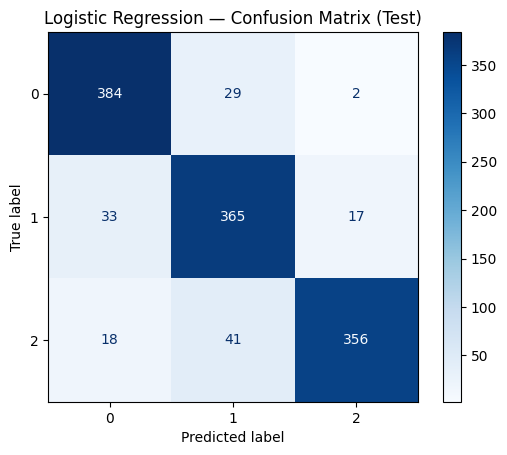

In [58]:
best_model_name = "Logistic Regression"
best_model_row = result_df[result_df['model'] == best_model_name].iloc[0]
best_model_obj = result[best_model_name]['model_obj']
best_acc = best_model_row['test_acc']

print(f"\nSelected classifier: {best_model_name}")
print(f"Test Accuracy: {best_acc:.4f}")

# Classification report & confusion matrix for best model
y_train_pred_best = best_model_obj.predict(X_train_scaled)
y_test_pred_best  = best_model_obj.predict(X_test_scaled)

print("\n--- Train Classification Report ---")
print(classification_report(y_train, y_train_pred_best))
print("\n--- Test Classification Report ---")
print(classification_report(y_test, y_test_pred_best))

cm = confusion_matrix(y_test, y_test_pred_best)
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', xticks_rotation='horizontal')
plt.title(f"{best_model_name} \u2014 Confusion Matrix (Test)")
plt.show()

In [59]:
best_model_obj

LogisticRegression(class_weight='balanced', max_iter=5000,
                   multi_class='multinomial', solver='saga')

16. ROC (Receiver Operating Characterstics) and AUC (Area Under Curve)

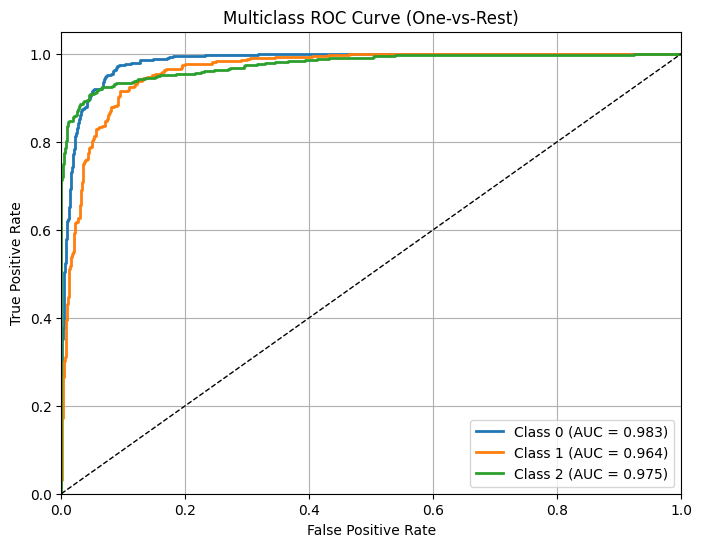

In [60]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_proba = best_model_obj.predict_proba(X_test_scaled)
classes = sorted(list(set(y_test)))
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(8, 6))
for i, class_label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"Class {class_label} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve (One-vs-Rest)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


Tnue only the best model

Tnue only the best model

17. Saving the Failure detection file

In [61]:
os.makedirs("Machine_Failure_POC/reports", exist_ok=True)
result_df.to_csv("Machine_Failure_POC/reports/best_model_summary.csv", index=False)
print("Classification summary saved")

joblib.dump(best_model_obj, "Machine_Failure_POC/models/best_classification_model.joblib")
joblib.dump(feature_cols, "Machine_Failure_POC/models/feature_cols.joblib")


Classification summary saved


['Machine_Failure_POC/models/feature_cols.joblib']

In [62]:
import pickle as pkl


In [63]:
import joblib
import os

# Make folders if they don't exist
os.makedirs("Machine_Failure_POC/models", exist_ok=True)

# 1) Save best CLASSIFICATION model (maintenance class)
joblib.dump(best_model_obj, "Machine_Failure_POC/models/best_classification_model.joblib")
joblib.dump(scaler_clf, "Machine_Failure_POC/models/scaler_classification.joblib")
joblib.dump(feature_cols, "Machine_Failure_POC/models/feature_cols.joblib")

print("Saved classification model, scaler, and feature_cols")


Saved classification model, scaler, and feature_cols


In [64]:
import joblib
import os

# Path to the saved model
model_path = "Machine_Failure_POC/models/best_classification_model.joblib"

# Load the model
loaded_model = joblib.load(model_path)

print(f"Model loaded successfully from {model_path}")
print(f"Type of loaded model: {type(loaded_model)}")

Model loaded successfully from Machine_Failure_POC/models/best_classification_model.joblib
Type of loaded model: <class 'sklearn.linear_model._logistic.LogisticRegression'>


In [65]:
best_model_obj



LogisticRegression(class_weight='balanced', max_iter=5000,
                   multi_class='multinomial', solver='saga')

In [66]:
scaler_clf

StandardScaler()

In [67]:
feature_cols

['Age',
 'Maintenance_Cost',
 'Downtime',
 'Maintenance_Frequency',
 'Failure_Event_Count',
 'Report_Length',
 'Word_Count',
 'Contain_Failure',
 'Contain_Wear',
 'Contain_Replace',
 'Severity_Score',
 'Efficiency',
 'Age_Group',
 'battery__Issue',
 'sensor__Issue',
 'circuit__Issue',
 'software__Issue',
 'overheat__Issue',
 'delay__Issue',
 'Maintenance_per_Fail',
 'FailRate_Per_Age',
 'Downtime_Per_Event',
 'Downtime_cu',
 'Cost_cu',
 'Failure_cu',
 'Failure_X_Downtime',
 'Sensor_X_Age',
 'Battery_X_Cost',
 'Cost_Is_Outlier',
 'Downtime_Is_Outlier',
 'Report_Severity_Level',
 'Device_Type_Defibrillator',
 'Device_Type_Infusion Pump',
 'Device_Type_MRI Scanner',
 'Device_Type_PET Scanner',
 'Device_Type_X-Ray Machine',
 'Manufacturer_ImagingTech',
 'Manufacturer_MedEquip',
 'Manufacturer_RescueTech',
 'Manufacturer_ScanPro',
 'Manufacturer_UltraMed',
 'Model_Model-150',
 'Model_Model-200',
 'Model_Model-250',
 'Model_Model-300',
 'Model_Model-350',
 'Model_Model-400',
 'Model_Model-45

In [68]:
print(best_model_obj.predict(X_test_scaled))


[2 1 0 ... 1 0 1]


In [69]:
sum(best_model_obj.predict(X_test_scaled) == 1)   # class 2 in zero-index


np.int64(435)

In [70]:
df["Maintenance_Class"].value_counts()


,count
Maintenance_Class,
1,1383
2,1383
3,1383
